# Keras Regression Code Along Project 

Let's now apply our knowledge to a more realistic data set. Here we will also focus on feature engineering and cleaning our data!

## The Data

We will be using data from a Kaggle data set:

https://www.kaggle.com/harlfoxem/housesalesprediction

#### Feature Columns
    
* id - Unique ID for each home sold
* date - Date of the home sale
* price - Price of each home sold
* bedrooms - Number of bedrooms
* bathrooms - Number of bathrooms, where .5 accounts for a room with a toilet but no shower
* sqft_living - Square footage of the apartments interior living space
* sqft_lot - Square footage of the land space
* floors - Number of floors
* waterfront - A dummy variable for whether the apartment was overlooking the waterfront or not
* view - An index from 0 to 4 of how good the view of the property was
* condition - An index from 1 to 5 on the condition of the apartment,
* grade - An index from 1 to 13, where 1-3 falls short of building construction and design, 7 has an average level of construction and design, and 11-13 have a high quality level of construction and design.
* sqft_above - The square footage of the interior housing space that is above ground level
* sqft_basement - The square footage of the interior housing space that is below ground level
* yr_built - The year the house was initially built
* yr_renovated - The year of the house’s last renovation
* zipcode - What zipcode area the house is in
* lat - Lattitude
* long - Longitude
* sqft_living15 - The square footage of interior housing living space for the nearest 15 neighbors
* sqft_lot15 - The square footage of the land lots of the nearest 15 neighbors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('kc_house_data.csv')

# Exploratory Data Analysis

In [3]:
print("First few rows of the dataset:")
print(df.head())

First few rows of the dataset:
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_ren

In [4]:

summary_stats = df.describe()

print(summary_stats)

                 id         price      bedrooms     bathrooms   sqft_living  \
count  2.161300e+04  2.161300e+04  21613.000000  21613.000000  21613.000000   
mean   4.580302e+09  5.400881e+05      3.370842      2.114757   2079.899736   
std    2.876566e+09  3.671272e+05      0.930062      0.770163    918.440897   
min    1.000102e+06  7.500000e+04      0.000000      0.000000    290.000000   
25%    2.123049e+09  3.219500e+05      3.000000      1.750000   1427.000000   
50%    3.904930e+09  4.500000e+05      3.000000      2.250000   1910.000000   
75%    7.308900e+09  6.450000e+05      4.000000      2.500000   2550.000000   
max    9.900000e+09  7.700000e+06     33.000000      8.000000  13540.000000   

           sqft_lot        floors    waterfront          view     condition  \
count  2.161300e+04  21613.000000  21613.000000  21613.000000  21613.000000   
mean   1.510697e+04      1.494309      0.007542      0.234303      3.409430   
std    4.142051e+04      0.539989      0.086517    

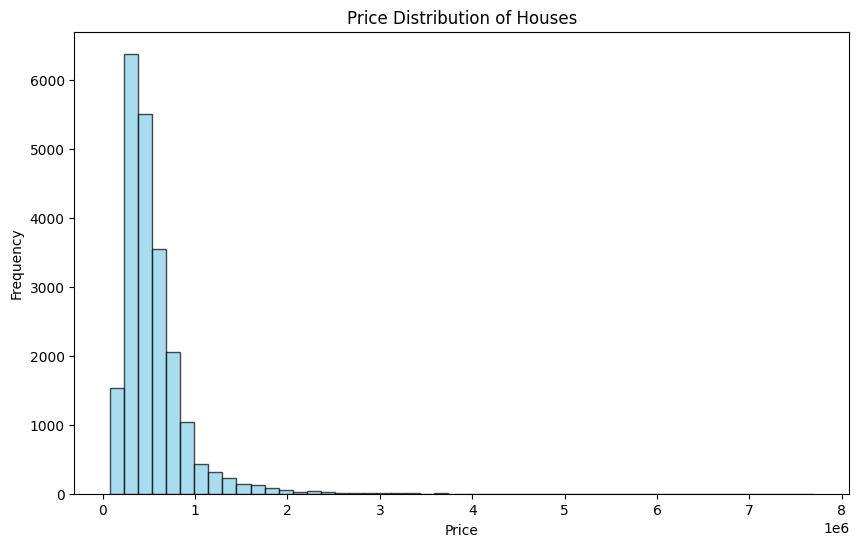

In [5]:
plt.figure(figsize=(10,6))
df['price'].plot(kind='hist', bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Price Distribution of Houses')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

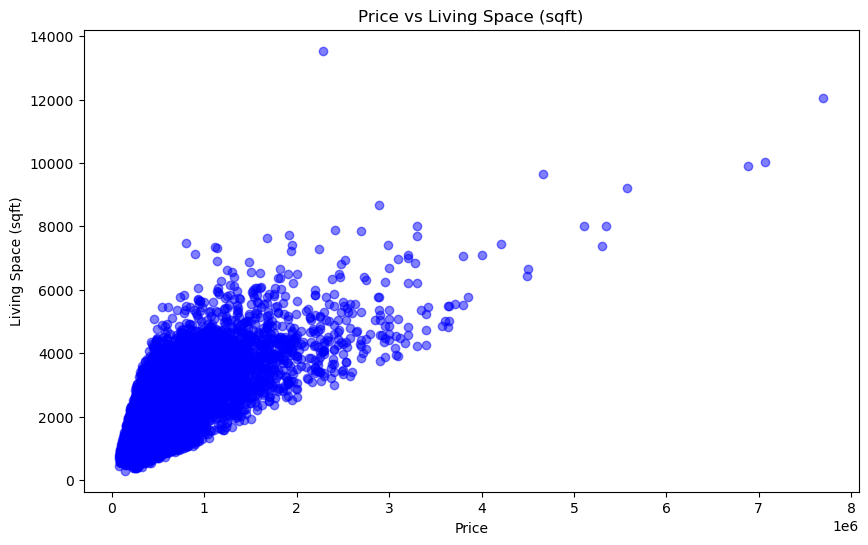

In [13]:
plt.figure(figsize=(10,6))
plt.scatter(df['price'], df['sqft_living'], color='blue', alpha=0.5)
plt.title('Price vs Living Space (sqft)')
plt.xlabel('Price')
plt.ylabel('Living Space (sqft)')
plt.show()

C:\Users\hosam\AppData\Local\Temp\ipykernel_18360\2925581026.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedrooms', y='price', data=df, palette='Set2')


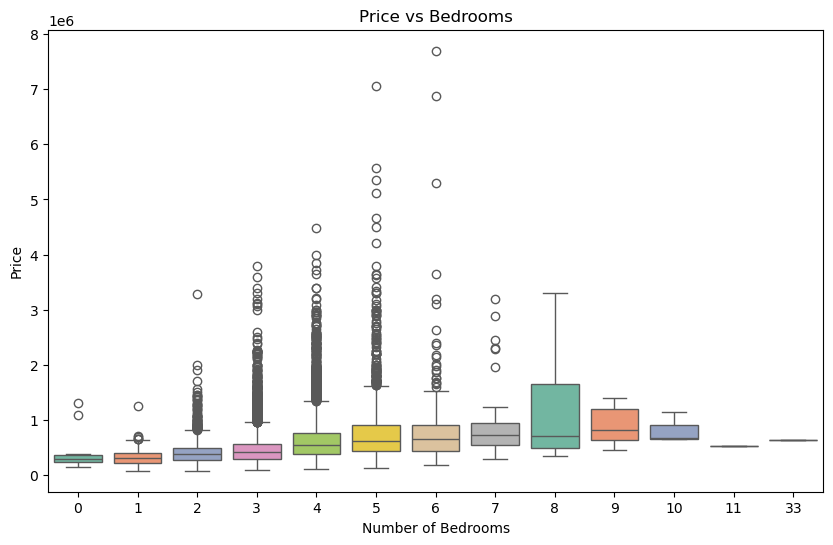

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='bedrooms', y='price', data=df, palette='Set2')
plt.title('Price vs Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.show()

C:\Users\hosam\AppData\Local\Temp\ipykernel_18360\1282089502.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='waterfront', y='price', data=df, palette='Set1')


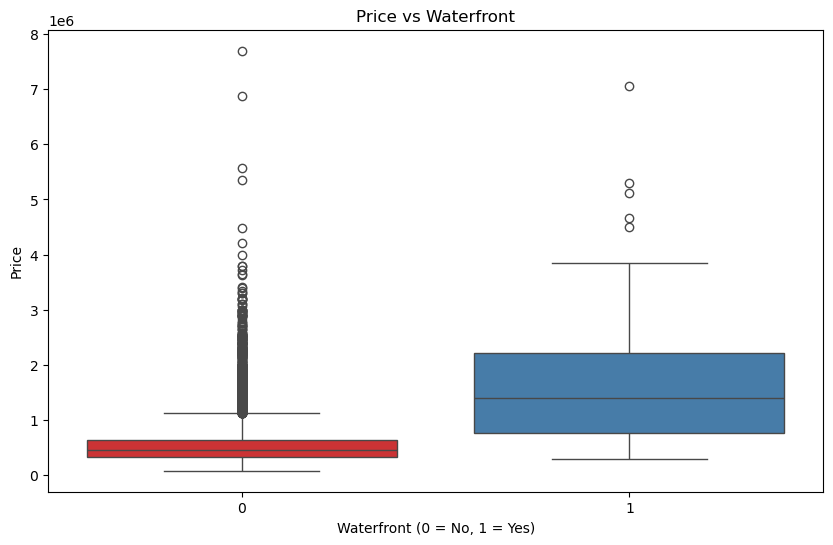

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x='waterfront', y='price', data=df, palette='Set1')
plt.title('Price vs Waterfront')
plt.xlabel('Waterfront (0 = No, 1 = Yes)')
plt.ylabel('Price')
plt.show()

## Working with Feature Data

In [19]:
print(df.head())

print(df.info())

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

In [18]:
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [20]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2/25/2015,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


- There is difference between the dataframes

### Feature Engineering from Date

In [3]:
df['date'] = pd.to_datetime(df['date'])
print(df.head())

           id       date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520 2014-10-13  221900.0         3       1.00         1180   
1  6414100192 2014-12-09  538000.0         3       2.25         2570   
2  5631500400 2015-02-25  180000.0         2       1.00          770   
3  2487200875 2014-12-09  604000.0         4       3.00         1960   
4  1954400510 2015-02-18  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     long  sqft_living15  \
0      1955    

In [4]:
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

print(df.head())

           id       date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520 2014-10-13  221900.0         3       1.00         1180   
1  6414100192 2014-12-09  538000.0         3       2.25         2570   
2  5631500400 2015-02-25  180000.0         2       1.00          770   
3  2487200875 2014-12-09  604000.0         4       3.00         1960   
4  1954400510 2015-02-18  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  sqft_basement  yr_built  \
0      5650     1.0           0     0  ...              0      1955   
1      7242     2.0           0     0  ...            400      1951   
2     10000     1.0           0     0  ...              0      1933   
3      5000     1.0           0     0  ...            910      1965   
4      8080     1.0           0     0  ...              0      1987   

   yr_renovated  zipcode      lat     long  sqft_living15  sqft_lot15  month  \
0             0    98178  47.5112 -122.257           1340   

In [5]:
df = df.select_dtypes(include=[np.number]) 

C:\Users\hosam\AppData\Local\Temp\ipykernel_18360\2330685870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='price', data=df, palette='Set2')


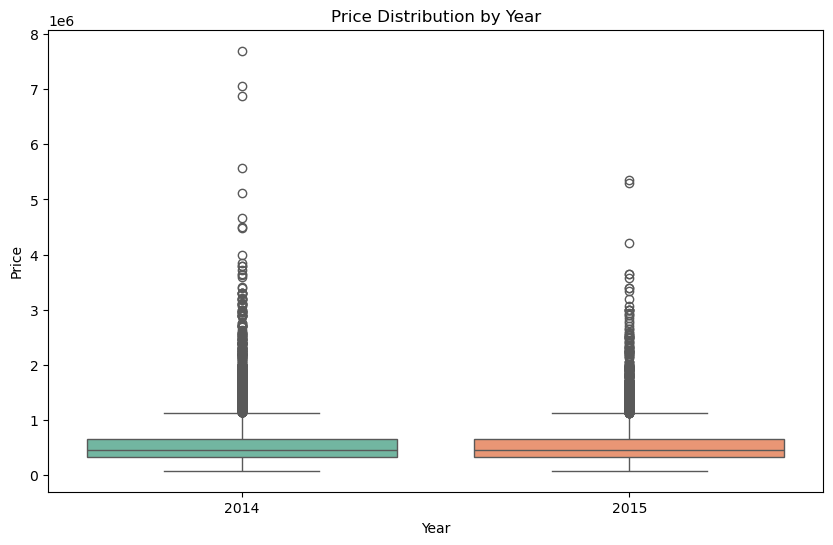

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(x='year', y='price', data=df, palette='Set2')
plt.title('Price Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

In [6]:
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01', format='%Y-%m-%d')

print(df['date'].head())

df['date'] = (df['date'] - df['date'].min()) / pd.Timedelta(days=1)

print(df.head())

0   2014-10-01
1   2014-12-01
2   2015-02-01
3   2014-12-01
4   2015-02-01
Name: date, dtype: datetime64[us]
           id     price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0  7129300520  221900.0         3       1.00         1180      5650     1.0   
1  6414100192  538000.0         3       2.25         2570      7242     2.0   
2  5631500400  180000.0         2       1.00          770     10000     1.0   
3  2487200875  604000.0         4       3.00         1960      5000     1.0   
4  1954400510  510000.0         3       2.00         1680      8080     1.0   

   waterfront  view  condition  ...  yr_built  yr_renovated  zipcode      lat  \
0           0     0          3  ...      1955             0    98178  47.5112   
1           0     0          3  ...      1951          1991    98125  47.7210   
2           0     0          3  ...      1933             0    98028  47.7379   
3           0     0          5  ...      1965             0    98136  47.5208   
4          

In [7]:
df['date'] = pd.to_datetime(df['date'])

df['date'] = (df['date'] - df['date'].min()) / pd.Timedelta(days=1)

print(df.head())

           id     price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0  7129300520  221900.0         3       1.00         1180      5650     1.0   
1  6414100192  538000.0         3       2.25         2570      7242     2.0   
2  5631500400  180000.0         2       1.00          770     10000     1.0   
3  2487200875  604000.0         4       3.00         1960      5000     1.0   
4  1954400510  510000.0         3       2.00         1680      8080     1.0   

   waterfront  view  condition  ...  yr_built  yr_renovated  zipcode      lat  \
0           0     0          3  ...      1955             0    98178  47.5112   
1           0     0          3  ...      1951          1991    98125  47.7210   
2           0     0          3  ...      1933             0    98028  47.7379   
3           0     0          5  ...      1965             0    98136  47.5208   
4           0     0          3  ...      1987             0    98074  47.6168   

      long  sqft_living15  sqft_lot15 

C:\Users\hosam\AppData\Local\Temp\ipykernel_18360\183127880.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='price', data=df, palette='Set1')


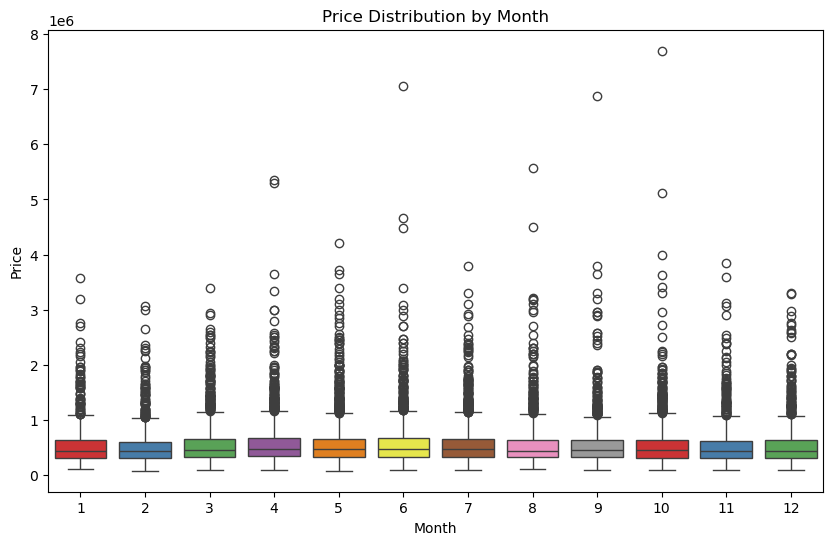

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(x='month', y='price', data=df, palette='Set1')
plt.title('Price Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Price')
plt.show()

In [25]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15', 'month', 'year'],
      dtype='object')

## Scaling and Train Test Split

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X = df.drop('price', axis=1)  
y = df['price']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {len(X_train)}')
print(f'Testing set size: {len(X_test)}')

Training set size: 17290
Testing set size: 4323


### Scaling

In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [11]:
X = df.select_dtypes(include=['float64', 'int64']).drop('price', axis=1)  # Ensure 'price' is not included

y = df['price']  
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df.head())

         id  bedrooms  bathrooms  sqft_living  sqft_lot    floors  waterfront  \
0  0.886146 -0.398737  -1.447464    -0.979835 -0.228321 -0.915427   -0.087173   
1  0.637511 -0.398737   0.175607     0.533634 -0.189885  0.936506   -0.087173   
2  0.365444 -1.473959  -1.447464    -1.426254 -0.123298 -0.915427   -0.087173   
3 -0.727656  0.676485   1.149449    -0.130550 -0.244014 -0.915427   -0.087173   
4 -0.912881 -0.398737  -0.149007    -0.435422 -0.169653 -0.915427   -0.087173   

       view  condition     grade  sqft_above  sqft_basement  yr_built  \
0 -0.305759  -0.629187 -0.558836   -0.734708      -0.658681 -0.544898   
1 -0.305759  -0.629187 -0.558836    0.460841       0.245141 -0.681079   
2 -0.305759  -0.629187 -1.409587   -1.229834      -0.658681 -1.293892   
3 -0.305759   2.444294 -0.558836   -0.891699       1.397515 -0.204446   
4 -0.305759  -0.629187  0.291916   -0.130895      -0.658681  0.544548   

   yr_renovated   zipcode       lat      long  sqft_living15  sqft_lot15  

## Creating a Model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [13]:
model = Sequential()

model.add(Dense(64, input_dim=X_train.shape[1]))  
model.add(Activation('relu'))

model.add(Dense(32)) 
model.add(Activation('relu'))

model.add(Dense(1))  
model.add(Activation('linear'))  

model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])

c:\Users\hosam\anaconda3\envs\myenv1\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Training the Model

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=400, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/400
541/541 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 10543637905539072.0000 - mae: 18506084.0000 - val_loss: 234396778496.0000 - val_mae: 323859.4688
Epoch 2/400
541/541 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 215959797760.0000 - mae: 319896.3125 - val_loss: 235149164544.0000 - val_mae: 330782.2188
Epoch 3/400
541/541 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 217208586240.0000 - mae: 321351.7500 - val_loss: 234093248512.0000 - val_mae: 321810.6562
Epoch 4/400
541/541 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 218040352768.0000 - mae: 322001.1250 - val_loss: 242554339328.0000 - val_mae: 322817.1250
Epoch 5/400
541/541 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 218229096448.0000 - mae: 321798.5312 - val_loss: 243390218240.0000 - val_mae: 347610.3438
Epoch 6/400
541/541 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 218011746304.0000 - mae: 322710.7500 - val_loss: 230632046592.0000 - val_mae: 323183.3750
Epoch 7/400
541/541 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 222225498112.0000 - mae: 3

In [47]:
losses = pd.DataFrame(model.history.history)

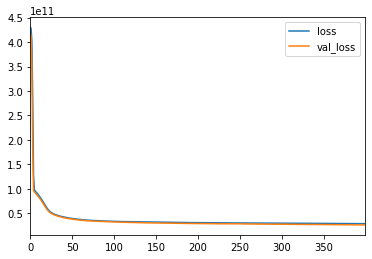

In [48]:
losses.plot()

# Evaluation on Test Data

https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics

In [16]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score

In [19]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
explained_variance = explained_variance_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Explained Variance Score: {explained_variance}')

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
Mean Squared Error: 182944949548.19467
Mean Absolute Error: 271825.95005638443
Explained Variance Score: -0.19409971631714829


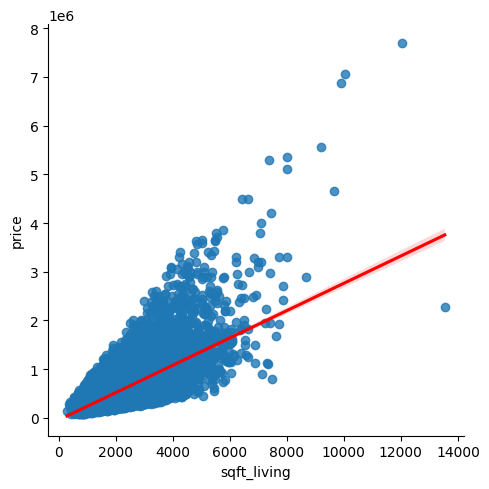

In [20]:
sns.lmplot(x='sqft_living', y='price', data=df, line_kws={'color': 'red'})

plt.show()